# Self-Attention in Transformers — Step by Step

This notebook walks through **self-attention** from scratch using pure NumPy, then with PyTorch, so you can see exactly what's happening at every stage.

### What is Self-Attention?
Self-attention lets every token in a sequence **look at every other token** and decide how much to "attend" to each one when building its own representation.

**Formula:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
torch.manual_seed(42)
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Step 0: Our Input — A Simple Sentence

We'll use the sentence: **"The cat sat"**

Each word gets represented as an embedding vector. For simplicity we use 4-dimensional embeddings.

In [3]:
# Vocabulary
tokens = ['The', 'cat', 'sat']
seq_len = 3    # number of tokens
d_model = 4   # embedding dimension

# Pretend these are our learned token embeddings (normally from nn.Embedding)
X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # 'The'
    [0.0, 2.0, 0.0, 2.0],  # 'cat'
    [1.0, 1.0, 1.0, 0.0],  # 'sat'
], dtype=np.float32)

print(f'Input shape: {X.shape}  → (seq_len={seq_len}, d_model={d_model})')
print(f'\nEmbedding matrix X:')
print(X)

Input shape: (3, 4)  → (seq_len=3, d_model=4)

Embedding matrix X:
[[1. 0. 1. 0.]
 [0. 2. 0. 2.]
 [1. 1. 1. 0.]]


---
## Step 1: Create Q, K, V Weight Matrices

Three learnable weight matrices project the input into **Query (Q)**, **Key (K)**, and **Value (V)** spaces.

- **Query**: What am I looking for?
- **Key**: What do I contain / advertise?
- **Value**: What do I actually give to others?

In [4]:
d_k = 4   # dimension of Q and K (and V here)

# Weight matrices (normally learned via backprop; here we initialize randomly)
W_Q = np.random.randn(d_model, d_k).astype(np.float32) * 0.5
W_K = np.random.randn(d_model, d_k).astype(np.float32) * 0.5
W_V = np.random.randn(d_model, d_k).astype(np.float32) * 0.5

print('W_Q shape:', W_Q.shape)
print('W_K shape:', W_K.shape)
print('W_V shape:', W_V.shape)

W_Q shape: (4, 4)
W_K shape: (4, 4)
W_V shape: (4, 4)


---
## Step 2: Compute Q, K, V

Project input X through each weight matrix:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

In [5]:
Q = X @ W_Q   # shape: (seq_len, d_k)
K = X @ W_K
V = X @ W_V

print('Q (Queries):')
print(np.round(Q, 3))
print('\nK (Keys):')
print(np.round(K, 3))
print('\nV (Values):')
print(np.round(V, 3))

Q (Queries):
[[ 0.014  0.202  0.092  0.529]
 [ 0.008 -2.147 -0.146  0.205]
 [-0.103  0.085  0.882  0.912]]

K (Keys):
[[-0.779  0.213 -1.03  -0.518]
 [ 0.865 -0.517 -0.534  0.428]
 [-0.046  0.1   -0.996 -1.231]]

V (Values):
[[ 0.362 -0.443  0.353 -0.761]
 [-1.27  -2.68  -1.789  1.254]
 [ 0.467 -1.423 -0.311 -0.663]]


---
## Step 3: Compute Attention Scores  (Q · Kᵀ)

Each query dot-products with every key to produce a **raw score** (how relevant is token j to token i?).

$$\text{scores} = Q K^T$$

In [6]:
scores = Q @ K.T    # shape: (seq_len, seq_len)

print('Raw attention scores (Q @ K.T):')
print(np.round(scores, 3))
print(f'\nShape: {scores.shape} → each row = one query attending to all keys')

Raw attention scores (Q @ K.T):
[[-0.336  0.084 -0.723]
 [-0.419  1.284 -0.322]
 [-1.282 -0.214 -1.988]]

Shape: (3, 3) → each row = one query attending to all keys


---
## Step 4: Scale the Scores

Divide by √d_k to prevent vanishing gradients from very large dot products.

$$\text{scaled\_scores} = \frac{QK^T}{\sqrt{d_k}}$$

In [7]:
scale = np.sqrt(d_k)
scaled_scores = scores / scale

print(f'Scaling factor: √{d_k} = {scale:.3f}')
print('\nScaled scores:')
print(np.round(scaled_scores, 3))

Scaling factor: √4 = 2.000

Scaled scores:
[[-0.168  0.042 -0.361]
 [-0.209  0.642 -0.161]
 [-0.641 -0.107 -0.994]]


---
## Step 5: Apply Softmax — Attention Weights

Softmax converts scores to probabilities (they sum to 1 per row). This gives us the **attention weights** — how much each token attends to every other token.

In [8]:
def softmax(x, axis=-1):
    e_x = np.exp(x - x.max(axis=axis, keepdims=True))  # subtract max for numerical stability
    return e_x / e_x.sum(axis=axis, keepdims=True)

attn_weights = softmax(scaled_scores)

print('Attention weights (each row sums to 1):')
print(np.round(attn_weights, 3))
print('\nRow sums:', np.round(attn_weights.sum(axis=1), 4))

Attention weights (each row sums to 1):
[[0.327 0.403 0.27 ]
 [0.228 0.533 0.239]
 [0.293 0.5   0.206]]

Row sums: [1. 1. 1.]


---
## Step 6: Visualize the Attention Map

The heatmap shows **who attends to whom**. Row = query token, column = key token.

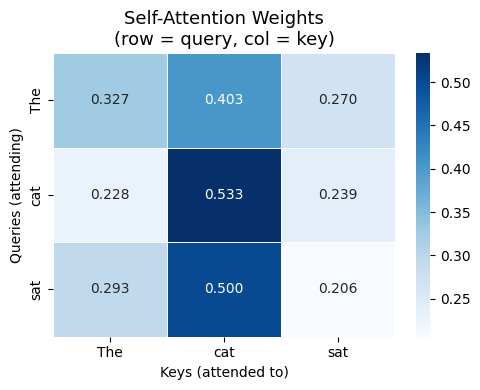

Brighter = more attention


In [9]:
plt.figure(figsize=(5, 4))
sns.heatmap(attn_weights, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=tokens, yticklabels=tokens,
            linewidths=0.5)
plt.title('Self-Attention Weights\n(row = query, col = key)', fontsize=13)
plt.xlabel('Keys (attended to)')
plt.ylabel('Queries (attending)')
plt.tight_layout()
plt.show()
print('Brighter = more attention')

---
## Step 7: Compute the Output — Weighted Sum of Values

Multiply attention weights by Values. Each token's output is a **weighted blend** of all value vectors.

$$\text{Output} = \text{Attention\_Weights} \cdot V$$

In [10]:
output = attn_weights @ V   # shape: (seq_len, d_k)

print('Self-Attention Output:')
print(np.round(output, 3))
print(f'\nShape: {output.shape} → same as input (seq_len, d_model)')

Self-Attention Output:
[[-0.268 -1.61  -0.69   0.079]
 [-0.483 -1.87  -0.948  0.337]
 [-0.433 -1.764 -0.855  0.268]]

Shape: (3, 4) → same as input (seq_len, d_model)


Each row is now a **context-aware** representation of that token — it has "seen" all other tokens.

---
## Step 8: Full Self-Attention in PyTorch

Now let's implement it cleanly as a PyTorch module.

In [11]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k = d_k
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        Q = self.W_Q(x)                        # (batch, seq, d_k)
        K = self.W_K(x)
        V = self.W_V(x)

        # Scaled dot-product attention
        scores = Q @ K.transpose(-2, -1) / self.d_k**0.5   # (batch, seq, seq)
        attn   = F.softmax(scores, dim=-1)
        out    = attn @ V                      # (batch, seq, d_k)
        return out, attn


# Run it
X_pt = torch.tensor(X).unsqueeze(0)   # add batch dim → (1, 3, 4)
attn_layer = SelfAttention(d_model=4, d_k=4)
out_pt, attn_pt = attn_layer(X_pt)
#X_pt = torch.tensor(X).unsqueeze(0)   # (1, 3, 4)

#ising_layer = IsingAttention(d_model=4, seq_len=3)
#out_ising, J_matrix = ising_layer(X_pt)

#print("Output shape:", out_ising.shape)
#print("Output:\n", out_ising.detach().numpy().round(3))

#print("\nLearned coupling matrix J:")
#print(J_matrix.detach().numpy().round(3))

print('Input shape:', X_pt.shape)
print('Output shape:', out_pt.shape)
print('Attention weights shape:', attn_pt.shape)
print('\nAttention weights:\n', attn_pt.detach().numpy().round(3))

Input shape: torch.Size([1, 3, 4])
Output shape: torch.Size([1, 3, 4])
Attention weights shape: torch.Size([1, 3, 3])

Attention weights:
 [[[0.469 0.159 0.372]
  [0.236 0.502 0.262]
  [0.453 0.173 0.374]]]


---
## Step 9: (Bonus) Multi-Head Attention

In practice, transformers run **multiple attention heads in parallel** — each head can learn different relationship patterns.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        # x: (batch, seq, d_model) → (batch, heads, seq, d_k)
        B, S, _ = x.shape
        return x.view(B, S, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, x):
        B, S, _ = x.shape
        Q = self.split_heads(self.W_Q(x))   # (B, h, S, d_k)
        K = self.split_heads(self.W_K(x))
        V = self.split_heads(self.W_V(x))

        scores = Q @ K.transpose(-2, -1) / self.d_k**0.5
        attn   = F.softmax(scores, dim=-1)
        out    = attn @ V                   # (B, h, S, d_k)

        # Concat heads → (B, S, d_model)
        out = out.transpose(1, 2).contiguous().view(B, S, -1)
        return self.W_O(out), attn


# Use 2 heads (d_model=4 → d_k=2 per head)
mha = MultiHeadAttention(d_model=4, num_heads=2)
out_mha, attn_mha = mha(X_pt)

print('Multi-head output shape:', out_mha.shape)
print('Attention shape (B, heads, seq, seq):', attn_mha.shape)

# Plot both heads
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for h, ax in enumerate(axes):
    w = attn_mha[0, h].detach().numpy()
    sns.heatmap(w, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=tokens, yticklabels=tokens,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Head {h+1} Attention')
    ax.set_xlabel('Keys'); ax.set_ylabel('Queries')
plt.suptitle('Multi-Head Attention Weights', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Step | What happens |
|------|--------------|
| 0 | Token embeddings → matrix X |
| 1 | Learn weight matrices W_Q, W_K, W_V |
| 2 | Compute Q = XW_Q, K = XW_K, V = XW_V |
| 3 | Raw scores = Q @ Kᵀ |
| 4 | Scale by 1/√d_k |
| 5 | Softmax → attention weights |
| 6 | Visualize the attention map |
| 7 | Output = attention_weights @ V |
| 8 | PyTorch module |
| 9 | Multi-head attention |

**Key intuition:** Each token computes a query (what it wants), each token emits a key (what it offers), and the dot product of query vs keys decides how much of each token's value gets mixed in. This is how transformers build context-aware representations.

In [11]:
class IsingAttention(nn.Module):
    def __init__(self, d_model, seq_len, num_iters=10):
        super().__init__()
        self.seq_len = seq_len
        self.num_iters = num_iters

        # Coupling matrix J (spin-spin interactions)
        self.J = nn.Parameter(
            torch.randn(seq_len, seq_len) / seq_len
        )

        # Optional projection (like V in transformer)
        self.proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        """
        x: (batch, seq_len, d_model)
        """

        # Initial spin state
        S = torch.zeros_like(x)

        for _ in range(self.num_iters):
            interaction = torch.einsum('ij,bjd->bid', self.J, S)
            S = torch.tanh(interaction + x)

        out = self.proj(S)

        return out, self.J

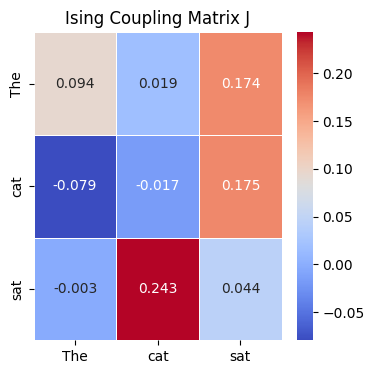

In [13]:
plt.figure(figsize=(4, 4))
sns.heatmap(J_matrix.detach().numpy(),
            annot=True, fmt='.3f',
            xticklabels=tokens,
            yticklabels=tokens,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Ising Coupling Matrix J")
plt.show()